# Magneto-quasistatics: Eddy-Current Shielding

The M-Statics-Coil notebook (static folder) solved a static coil field. Here the current is
time-harmonic at $50\;\text{Hz}$, and a conducting plate is placed between the coil
and the far side of the domain. A changing magnetic field induces currents in the
plate, those currents produce a field of their own, and the two partly cancel —
this is eddy-current shielding.

The governing equation gains one term relative to the static case,

$$\nabla \times \left(\nu\, \nabla \times \vec{A}\right) + j\omega\sigma \vec{A} = \vec{J}_s ,$$

which in FIT reads

$$\left(\mathbf{C}^\mathsf{T} \mathbf{M}_\nu \mathbf{C} + j\omega \mathbf{M}_\sigma\right) \hat{a} = \hat{\hat{\jmath}}_s .$$

The displacement current is dropped: at $50\;\text{Hz}$ the wavelength is thousands
of kilometres, so the problem is quasi-static and the fields are governed by
diffusion rather than propagation.

Two consequences follow from the new term. The system is now **complex**, since
$\hat{a}$ carries an amplitude and a phase — the induced currents lag the driving
field, and that lag is what makes the cancellation work. And the matrix is complex
*symmetric* but no longer Hermitian, so the conjugate-gradient method used in the
static notebook does not apply; a general non-symmetric Krylov method is needed.

The scale that decides whether shielding happens at all is the skin depth,

$$\delta = \sqrt{\frac{2}{\omega \mu \sigma}} ,$$

the distance over which the field falls by a factor $e$ inside the conductor. A
plate several skin depths thick shields well; one thinner than $\delta$ barely
shields at all.

The cell that follows loads the package and defines the boundary projection and
the analytical free-space reference from the static notebook.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."); io = devnull)
Pkg.develop(path = joinpath(@__DIR__, "..", ".."); io = devnull)
using FITToolbox;
using Statistics
using LinearAlgebra
using CairoMakie
using IterativeSolvers
using SparseArrays

function get_tangential_boundary(config::FITDomain)
    diag_vec = ones(Float64, 3*config.Np)
    # zero out the tangential entries; the rest pass through unchanged
    diag_vec[get_all_tangential_boundary_indices(config)] .= 0.0
    return spdiagm(0 => diag_vec)
end

get_tangential_boundary (generic function with 1 method)

## Domain, coil and shielding plate

A $100 \times 100 \times 100\;\text{cm}$ vacuum domain at $1\;\text{cm}$
resolution. The coil has radius $10\;\text{cm}$, sits at $x = 30\;\text{cm}$ and is
normal to $x$, so it lies in the $y$–$z$ plane. Everything is specified in
centimetres; note that `MyDomain.nodes_*` store metres, so the two centre
coordinates read back from the domain are scaled by $100$ before being passed on
with `units="cm"`.

`create_cube!` places the shielding plate downstream of the coil: origin at
$x = 40\;\text{cm}$ with a thickness of $10\;\text{cm}$, spanning $10$ to
$90\;\text{cm}$ in $y$ and $z$. Its conductivity is
$\sigma = 5.8\times10^7\;\text{S/m}$ — copper.

That choice sets the skin depth at $50\;\text{Hz}$:

$$\delta = \sqrt{\frac{2}{\omega\mu\sigma}} \approx 9.3\;\text{mm} .$$

The plate is therefore about **eleven skin depths** thick, and a plane wave
crossing it would be attenuated by $e^{-10.7} \approx 2\times10^{-5}$. Strong
shielding is expected, and the field behind the plate should drop to the bottom of
any sensible colour scale.

This is worth stating explicitly because the result is sensitive to it. Lowering
$\sigma$ to $10^{6}\;\text{S/m}$ gives $\delta \approx 7\;\text{cm}$, barely one and
a half skin depths through the same plate and an attenuation of only about a
quarter — real, but invisible on a plot whose colour range spans several decades.
The skin depth, not the conductivity alone, is what decides whether the effect will
be visible.

Note also that the plate leaves only $10\;\text{cm}$ of clearance to the domain
walls in $y$ and $z$. Field can leak around its edges through that gap, so the
attenuation measured behind the plate will be less than the one-dimensional
estimate above.

In [2]:
MyDomain = create_domain([100,100,100],[1,1,1];units="cm",σ=0,ε_r=1,μ_r=1); 

x_center = 30
y_center = MyDomain.nodes_v[end] / 2 * 100 # convert m to cm
z_center = MyDomain.nodes_w[end] / 2 * 100 # convert m to cm

coil_current = 1 #A
coil_radius = 10.0 #cm
wire = create_circular_loop_source(MyDomain,coil_radius,x_center,y_center,z_center,DirX();units="cm");
J = coil_current .* wire;


create_cube!(MyDomain, x_center + 10 , 10, 10, 10, 80, 80; units="cm", σ=5.8e7, ε_r=1.0, μ_r=1.0)

## Assembling the quasi-static system

Two material matrices are needed now. $\mathbf{M}_\nu$ is the reluctivity, as in
the static case; $\mathbf{M}_\sigma$ is the conductivity, built from the same cell
data that `create_cube!` wrote, so it is zero everywhere except in the plate.

The boundary projection is applied from the left, giving
$\mathbf{n}\times\vec{B}=0$ on all six faces — the same magnetic wall used in the
static notebook, so the two results are directly comparable.

The system matrix

$$\mathbf{A} = \mathbf{C}^\mathsf{T}\mathbf{M}_\nu\mathbf{C} + j\omega\mathbf{M}_\sigma$$

adds the induced-current term to the static operator. Three things follow from
that addition.

**The matrix is complex symmetric, not Hermitian.** $\mathbf{A}^\mathsf{T} = \mathbf{A}$
holds, but $\mathbf{A}^\dagger \neq \mathbf{A}$, because the conductivity term is
purely imaginary. Conjugate gradients relies on the Hermitian property and does not
apply here; the next cell uses BiCGStab instead.

**The gauge freedom survives, but only outside the conductor.** Inside the plate
the diagonal $j\omega\mathbf{M}_\sigma$ term determines the potential, so the null
space of the curl–curl operator is broken there. In the surrounding vacuum
$\sigma = 0$ and the freedom remains. The result is a system that is neither
cleanly singular nor definite, which is harder for an iterative solver than either
extreme.

**The two terms differ enormously in scale.** In the plate
$\omega\sigma \approx 1.8\times10^{10}$, while the reluctivity entries are of order
$\nu = 1/\mu_0 \approx 8\times10^5$ times a geometric ratio. The jump at the
conductor surface is what makes this problem badly conditioned, and it is why the
solve below takes far more iterations than the static one.

Note that $\mathbf{M}_\sigma$ is not projected by $\mathbf{P}$. That is deliberate:
the boundary condition constrains the flux, which lives on facets, whereas the
conductivity acts on edges. Applying the same projection to both would mix the two.

In [3]:
M_ν = get_reluctivity(MyDomain);
M_σ = get_conductivity(MyDomain)

# use 50 Hz problem
ω = 2π * 50
P = get_tangential_boundary(MyDomain)
C = P*get_curl(MyDomain, Primal())
A = C' * M_ν * C + im * ω * M_σ 

3090903×3090903 SparseMatrixCSC{ComplexF64, Int64} with 38665836 stored entries:
⎡⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠘⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⎥
⎢⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⎥
⎢⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⎥
⎢⠲⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⎥
⎢⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⎦

## Solving

BiCGStab handles the complex non-Hermitian system. The residual printed below is
computed directly from the result rather than read from the iteration history — on
a system that is singular in part of the domain, the recurrence residual can
stagnate in the null direction while the true one is fine.

Convergence is much slower here than in the static case. The cause is the
conductivity contrast: the eigenvalue spread widens with $\omega\sigma$, and the
iteration count grows roughly as the square root of the condition number. If the
run stalls rather than converges, a Jacobi preconditioner is the first thing to
try — the diagonal varies by orders of magnitude between plate and vacuum, which
is exactly the situation diagonal scaling helps.

Worth noting that the same preconditioner is useless on the static problem, where
the diagonal is nearly constant and scaling by it changes nothing. Whether a
preconditioner helps depends on what the diagonal actually contains, not on the
solver.

In [4]:
â, history = bicgstabl(A, J; reltol=1e-10, max_mv_products=4000, log=true)
println("Converged:     ", history.isconverged)
println("True residual: ", norm(A*â - J) / norm(J))

Converged:     true
True residual: 3.813018717905296e-11


## The shielded field

The cut is taken at $z = z_\text{center}$, a plane containing the coil axis, so the
coil appears as its two crossing points and the plate as a rectangle in profile.
Both are drawn on top of the heatmap in red.

Because the solution is complex, two different quantities could be plotted and
they mean different things. The heatmap shows the **phasor amplitude**
$\sqrt{|B_x|^2 + |B_y|^2 + |B_z|^2}$ — the envelope of the field over one cycle,
with the phase discarded. The arrows show the **real part**, the field at one
instant, which is what gives them a direction at all: an amplitude is positive
everywhere and has no sign to point with. The two are consistent but not
interchangeable, and the arrows would rotate if the phase reference were shifted.

The colour range is fixed at $10^{-9}$ to $10^{-5}\;\text{T}$ rather than
auto-scaled. That matters here: the near field at the coil is orders of magnitude
stronger than anything behind the plate, so an automatic range would compress the
shielded region into a single dark shade and hide the effect being studied. Fixing
the range costs saturation near the coil and buys visibility where it counts.

Two features stand out. Behind the plate the field falls sharply — eleven skin
depths of copper is close to an ideal shield — and the boundary of the drop
coincides with the drawn rectangle. Around the plate edges the field leaks through
the $10\;\text{cm}$ gaps to the domain walls, so the shadow is not complete: the
shielded region is bounded by the plate's extent, not by its thickness.

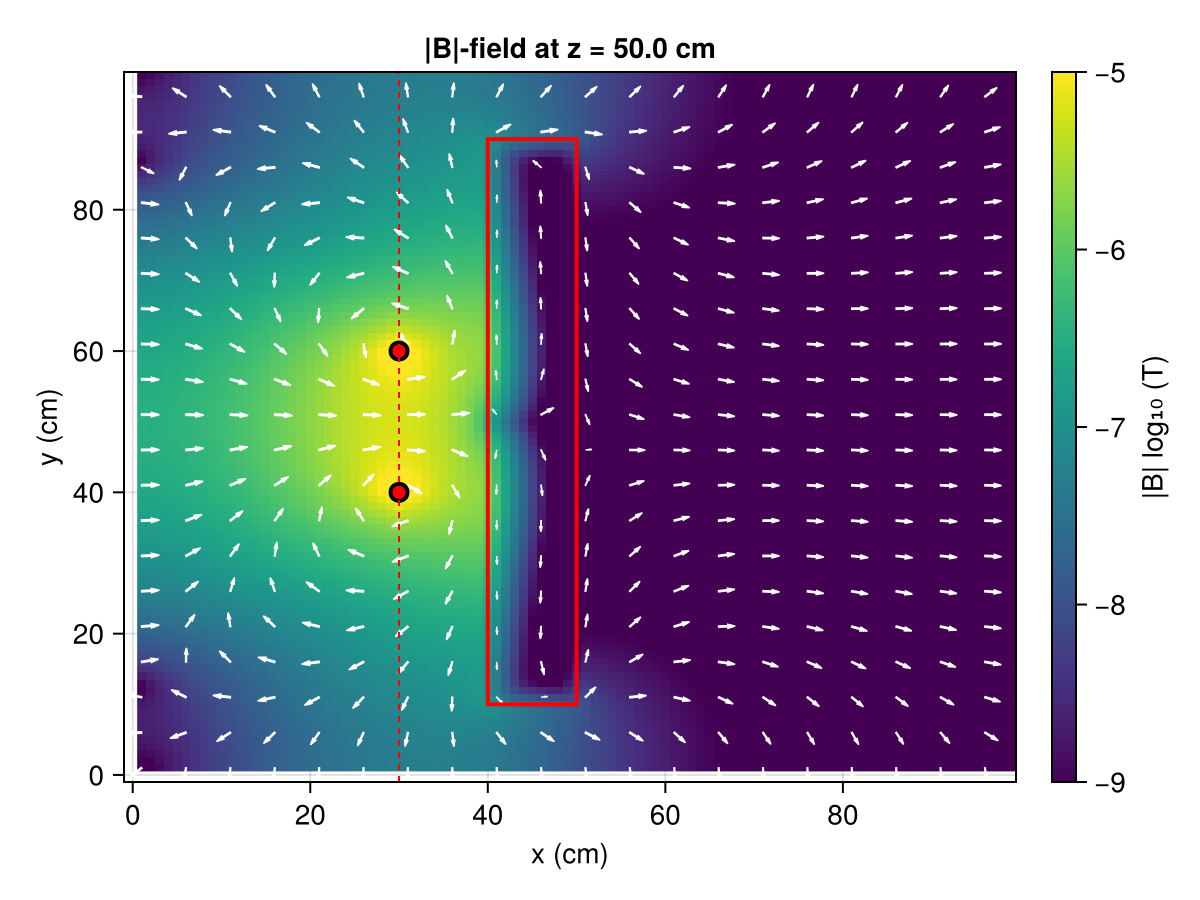

In [5]:
# Calculate magnetic flux from line integrated vector potential
b̂̂ = C * â

xs = ys = 1.0:99.0

# Sample the three components on the cut plane in one pass.
B = [FITToolbox.interpolate(MyDomain, PrimalFacet(), b̂̂, x, y, Float64(z_center); units="cm")
     for x in xs, y in ys]
Bmag = [hypot(abs.(b)...) for b in B]

# Subsample for the arrows and normalise them to equal length, so direction is
# readable where |B| spans decades.
step = 5
sub  = 1:step:length(xs)
u = [real(B[i,j][1]) / (Bmag[i,j] + eps()) * 2 for i in sub, j in sub]
v = [real(B[i,j][2]) / (Bmag[i,j] + eps()) * 2 for i in sub, j in sub]

fig, ax, hm = heatmap(xs, ys, log10.(Bmag); colormap = :viridis,
                      colorrange = (-9, -5))     # adjust to your values
                      Colorbar(fig[1,2], hm; label = "|B| log₁₀ (T)")

arrows2d!(ax, xs[sub], ys[sub], u, v;
          tiplength = 8, tipwidth = 6, color = :white)

# Geometry, in the same units as xs/ys
plate_u  = (40.0, 50.0)      # create_cube! origin 40 cm, thickness 10 cm
plate_v  = (10.0, 90.0)
coil_u   = 30.0
coil_r   = 10.0

# Plate outline
lines!(ax, [plate_u[1], plate_u[2], plate_u[2], plate_u[1], plate_u[1]],
           [plate_v[1], plate_v[1], plate_v[2], plate_v[2], plate_v[1]];
       color = :red, linewidth = 2)

# Coil: an X-normal loop cuts this plane at two points
scatter!(ax, [coil_u, coil_u], [y_center - coil_r, y_center + coil_r];
         color = :red, marker = :circle, markersize = 12, strokewidth = 2)

# Coil plane, for orientation
vlines!(ax, coil_u; color = :red, linestyle = :dash, linewidth = 1)

ax.title = "|B|-field at z = $(round(z_center, digits=2)) cm"
ax.xlabel = "x (cm)"
ax.ylabel = "y (cm)"
fig